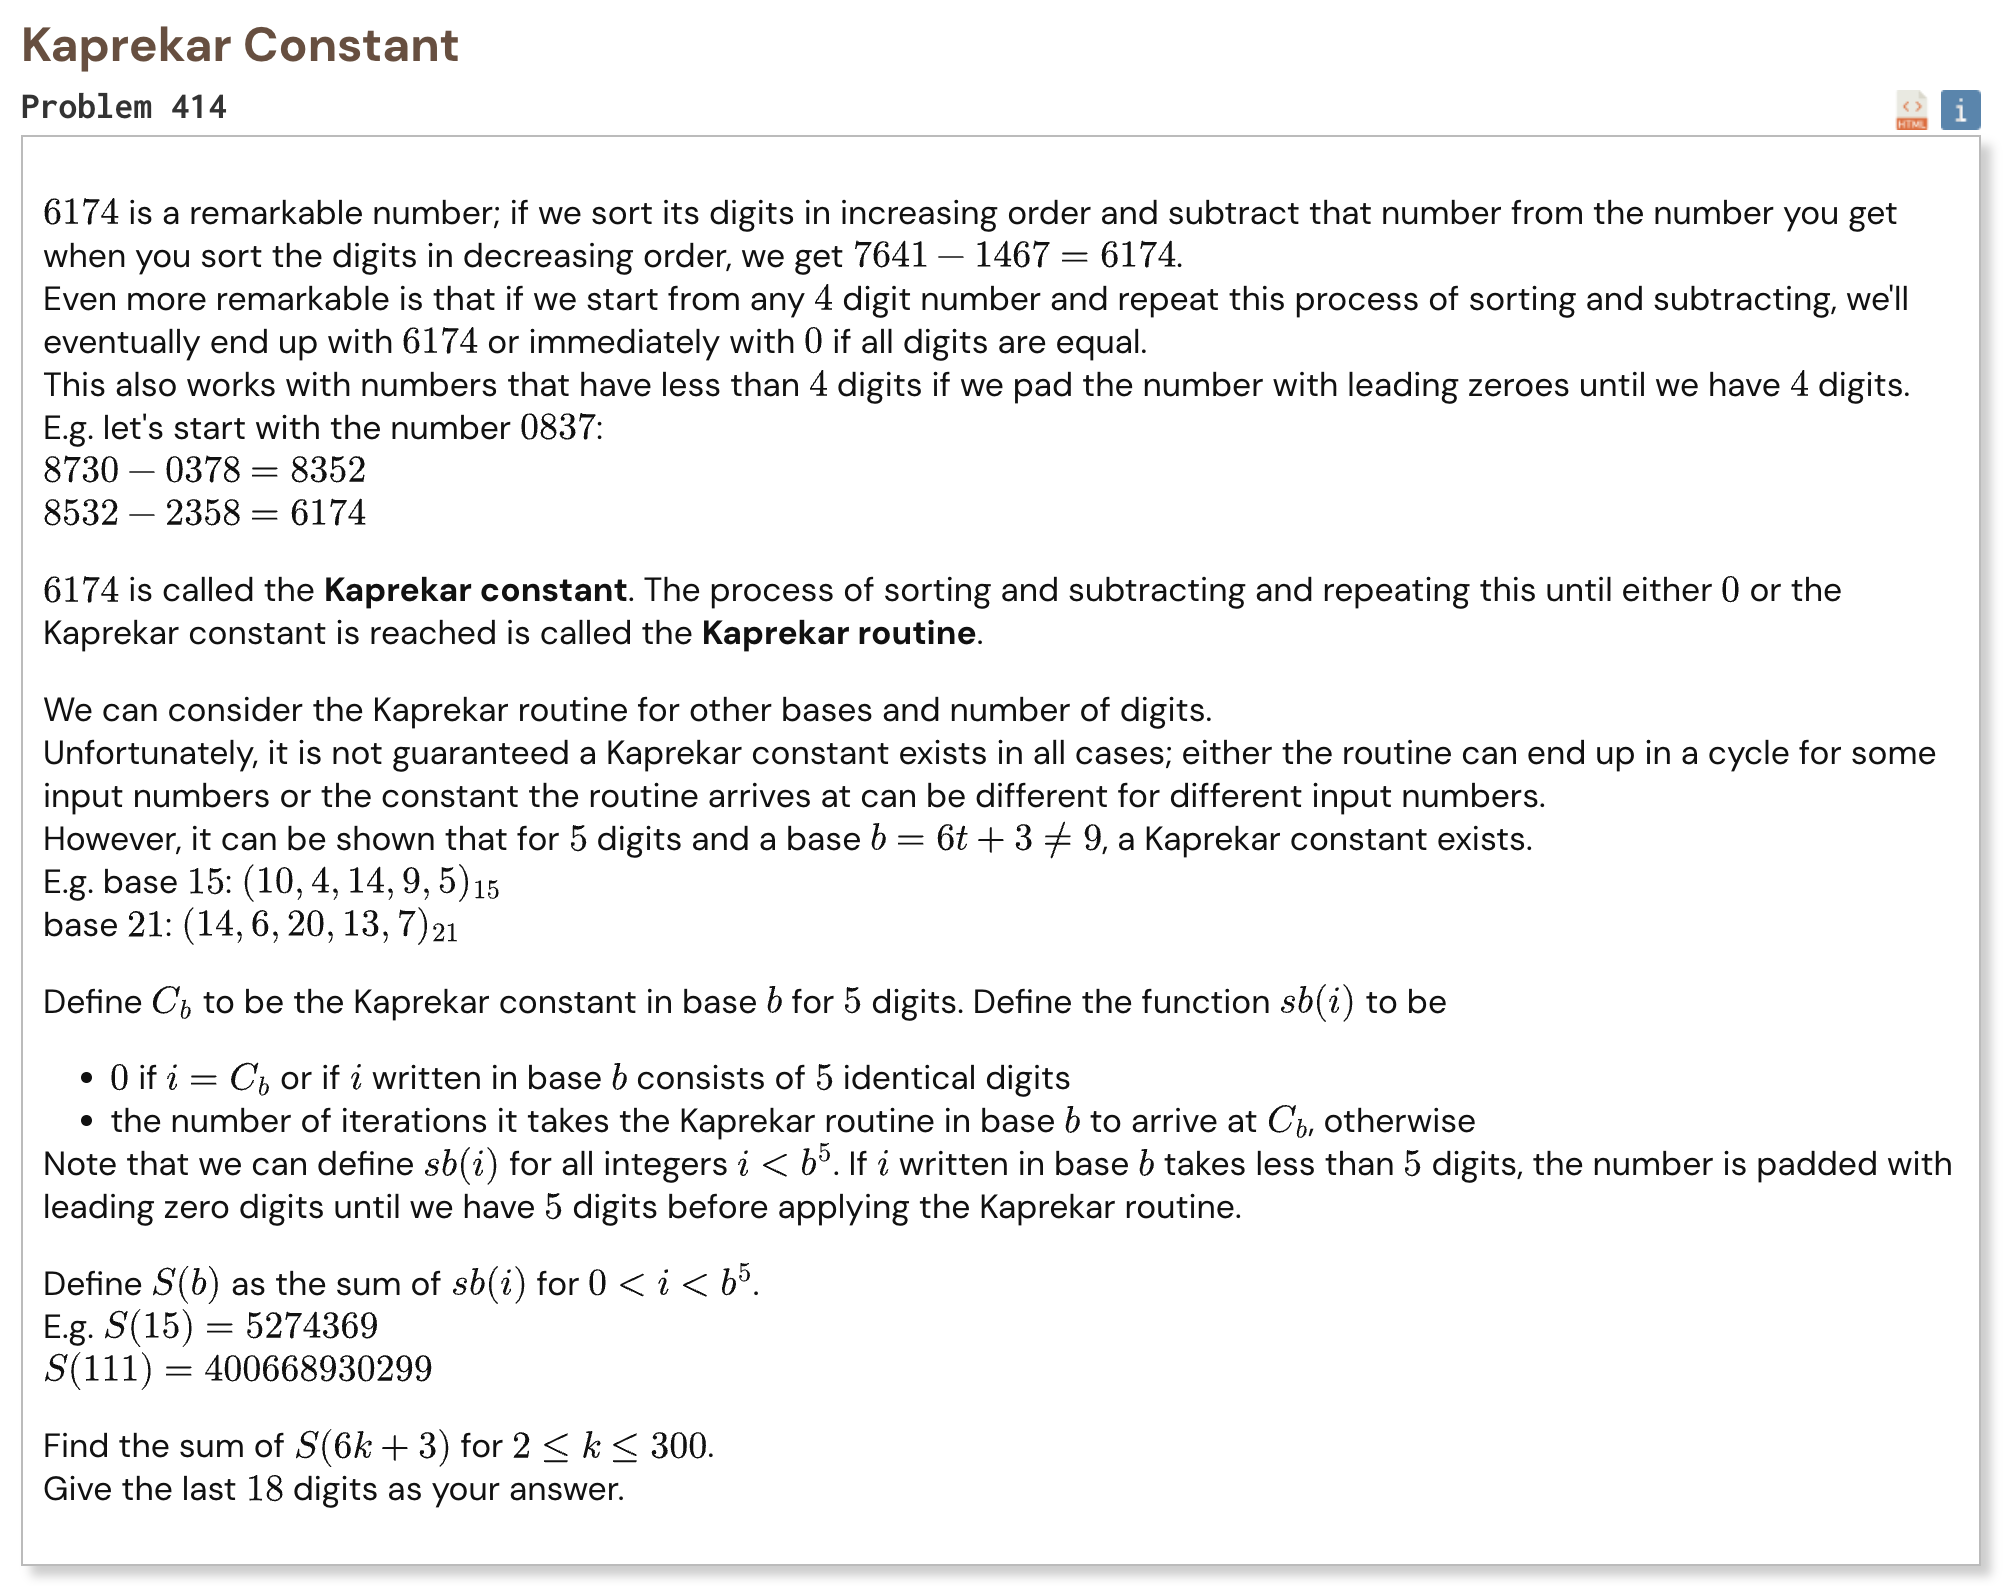

## Initial approach

-   group five digit numbers by the differences between their largest and smallest digits and their second largest and second smallest digits
-   numbers in the same group always produce the same next Kaprekar state
-   this reduces billions of possible numbers to only about half the square of the base
-   count how many original numbers belong to every state instead of checking them one by one
-   build the next state for every group and find how many steps it needs to reach the Kaprekar constant
-   multiply each distance by the number of values represented by that state and add everything together
-   repeat this for every required base and keep only the last eighteen digits
-   use array to store millions of small integers with much less memory than normal Python lists

```python

%%time

from array import array

MOD = 10**18

def index(p, q):
    return p * (p + 1) // 2 + q

def sort_four(a, b, c, d):
    if a > b:
        a, b = b, a
    if c > d:
        c, d = d, c
    if a > c:
        a, c = c, a
    if b > d:
        b, d = d, b
    if b > c:
        b, c = c, b
    return a, b, c, d

def calculate_s(base):
    t = (base - 3) // 6

    target_p = 4 * t + 2
    target_q = 2 * t + 1
    target = index(target_p, target_q)

    size = base * (base + 1) // 2

    next_state = array("I", [0]) * size
    weight = array("Q", [0]) * size

    for p in range(1, base):
        start = index(p, 0)
        remaining = base - p

        low = min(p - 1, remaining)
        high = max(p - 1, remaining)

        next_p = base - 1 - low
        next_q = base - 1 - high

        next_state[start] = index(next_p, next_q)
        weight[start] = remaining * (20 * p - 10)

        for q in range(1, p + 1):
            a, b, c, d = sort_four(
                p,
                remaining,
                q - 1,
                base - q - 1
            )

            next_p = base - 1 - a
            next_q = d - b

            state = start + q
            next_state[state] = index(next_p, next_q)

            if q == p:
                weight[state] = remaining * (30 * p - 10)
            else:
                weight[state] = remaining * (
                    120 * q * (p - q) - 20
                )

    distance = array("h", [-1]) * size
    distance[0] = 0
    distance[target] = 0

    total = 0

    for start in range(1, size):
        if distance[start] != -1:
            continue

        path = []
        state = start

        while distance[state] == -1:
            path.append(state)
            state = next_state[state]

        steps = distance[state]

        for state in reversed(path):
            steps += 1
            distance[state] = steps
            total += weight[state] * (steps + 1)

    total += weight[target]
    total -= 1

    return total % MOD

result = 0

for k in range(2, 301):
    base = 6 * k + 3
    result = (result + calculate_s(base)) % MOD

print("Result:", result)

````

- needs an optimzation